In [1]:
from keras.applications.vgg16 import VGG16
model = VGG16()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 26s 0us/step


In [2]:
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
from keras.utils import plot_model
plot_model(model, to_file='vgg16_model.png', show_shapes=True, show_layer_names=True)
print("Model architecture plot saved to 'vgg16_model.png'")

Model architecture plot saved to 'vgg16_model.png'


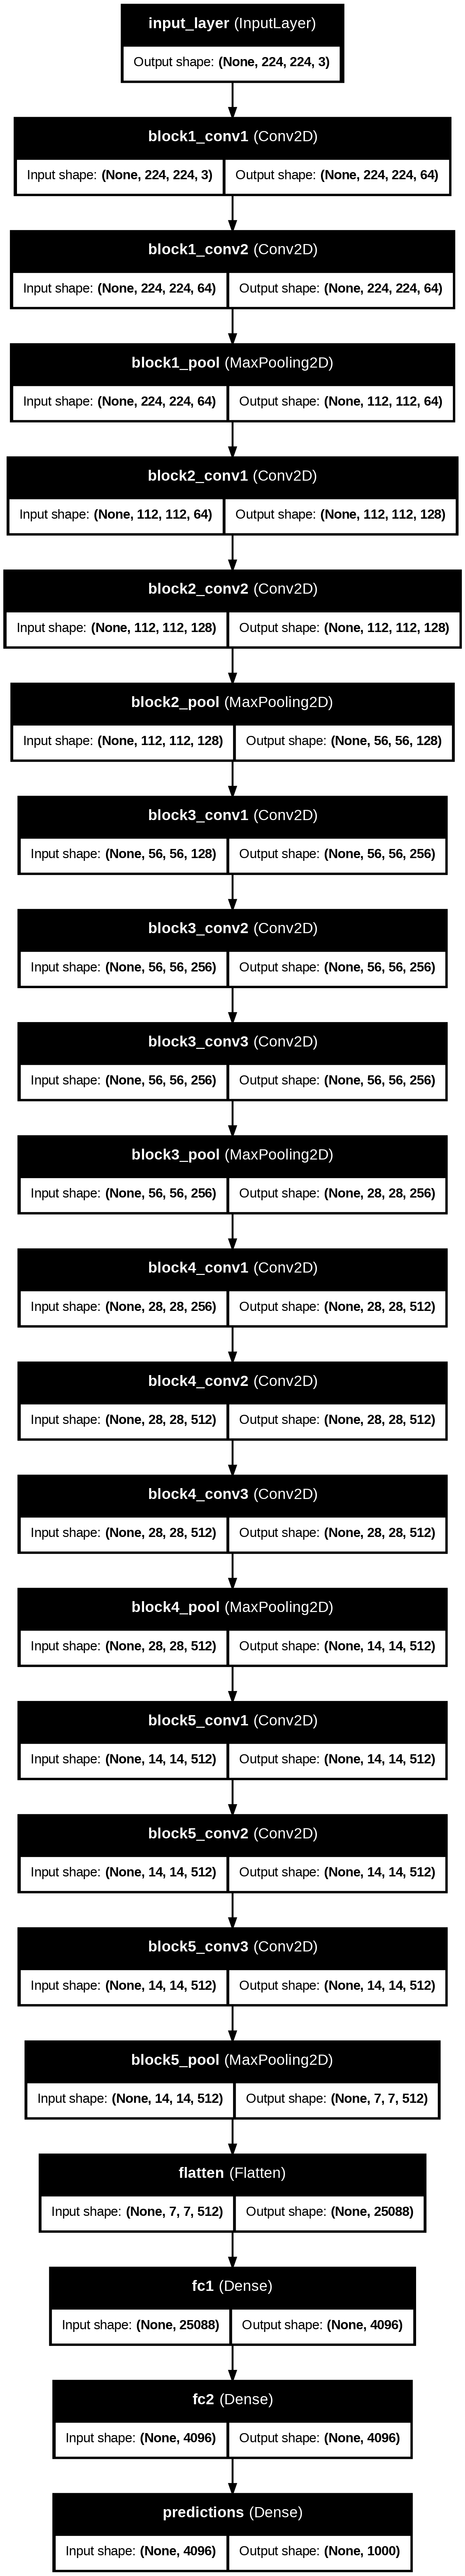

In [7]:
from IPython.display import Image
Image('vgg16_model.png', width=400)

In [9]:
for i in range(len(model.layers)):
  #check for convolution layer
  if 'conv' not in model.layers[i].name:
    continue
  #get filter weights
  filters,biases = model.layers[i].get_weights()
  print("layer nummber", i ,model.layers[i].name, filters.shape)

layer nummber 1 block1_conv1 (3, 3, 3, 64)
layer nummber 2 block1_conv2 (3, 3, 64, 64)
layer nummber 4 block2_conv1 (3, 3, 64, 128)
layer nummber 5 block2_conv2 (3, 3, 128, 128)
layer nummber 7 block3_conv1 (3, 3, 128, 256)
layer nummber 8 block3_conv2 (3, 3, 256, 256)
layer nummber 9 block3_conv3 (3, 3, 256, 256)
layer nummber 11 block4_conv1 (3, 3, 256, 512)
layer nummber 12 block4_conv2 (3, 3, 512, 512)
layer nummber 13 block4_conv3 (3, 3, 512, 512)
layer nummber 15 block5_conv1 (3, 3, 512, 512)
layer nummber 16 block5_conv2 (3, 3, 512, 512)
layer nummber 17 block5_conv3 (3, 3, 512, 512)


In [10]:
filters,bias = model.layers[1].get_weights()

In [11]:
f_min,f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

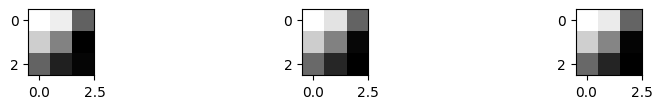

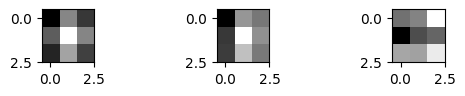

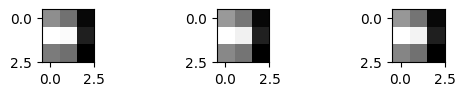

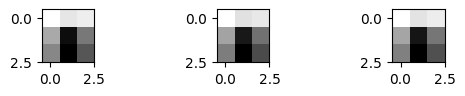

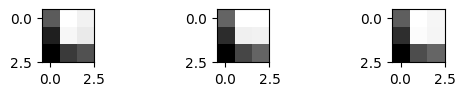

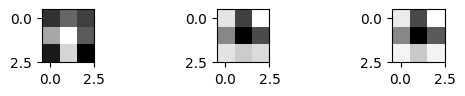

In [14]:
import matplotlib.pyplot as pyplot
n_filters = 6
ix = 1
fig = pyplot.figure(figsize= (10,6))
for i in range(n_filters):
  f = filters[:,:,:,i]
  for j in range(3):
    pyplot.subplot(n_filters,3,ix)
    pyplot.imshow(f[:,:,j],cmap = 'gray')
    ix = ix + 1

  pyplot.show()

In [20]:
from keras.models import Model
feature_map_model = Model(inputs=model.inputs, outputs=model.layers[1].output)

In [27]:
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input
from numpy import expand_dims

image = load_img('/content/human.avif', target_size = (224,224))
image = img_to_array(image)
image = expand_dims(image,axis = 0)
image = preprocess_input(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


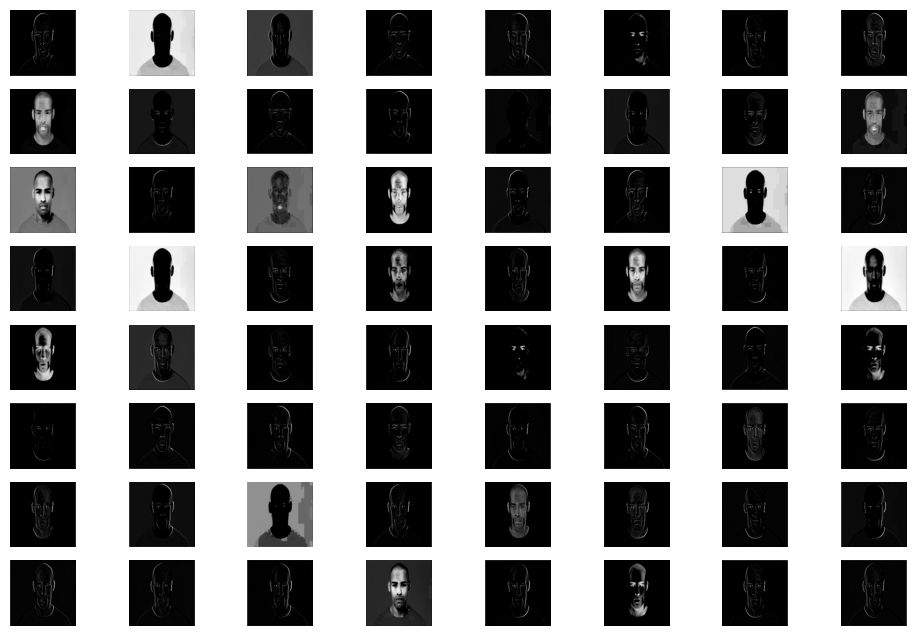

In [29]:
# Use feature_map_model to get the 4D feature maps
features = feature_map_model.predict(image)

fig = pyplot.figure(figsize = (12,8))
# The first layer has 64 channels, so we can plot them in an 8x8 grid
for i in range(1, features.shape[3] + 1):
    pyplot.subplot(8, 8, i)
    pyplot.axis('off')
    pyplot.imshow(features[0, :, :, i-1], cmap='gray')
pyplot.show()

In [31]:
model2 = VGG16()

In [35]:
layer_index = [2, 5, 9, 13, 17]
outputs = []
for i in layer_index:
    outputs.append(model2.layers[i].output)

model3 = Model(inputs=model2.inputs, outputs=outputs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


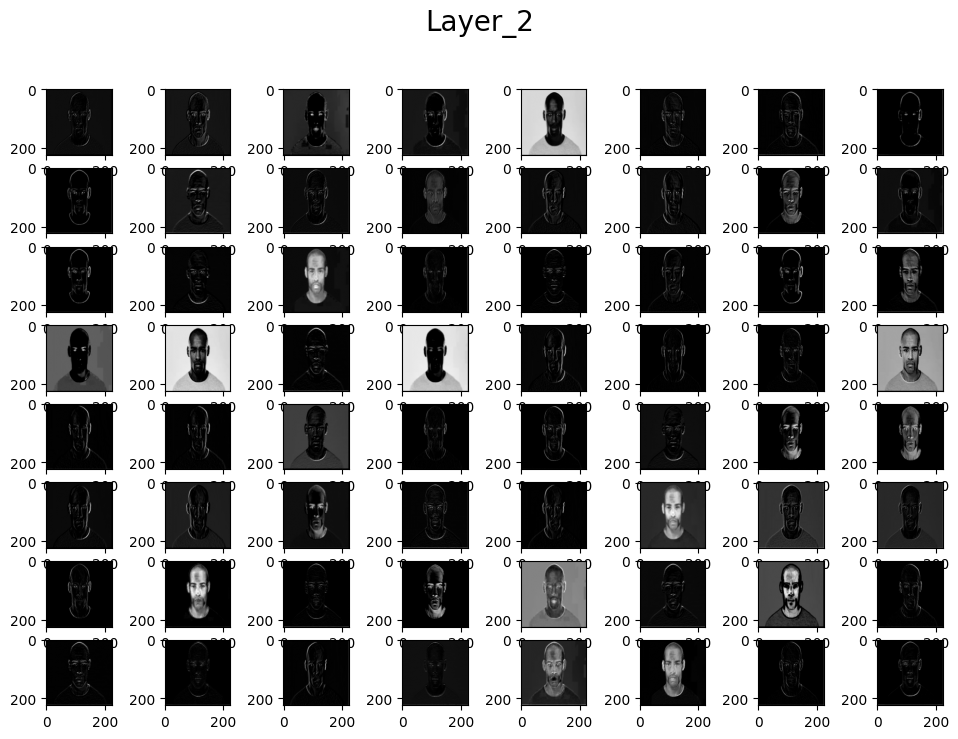

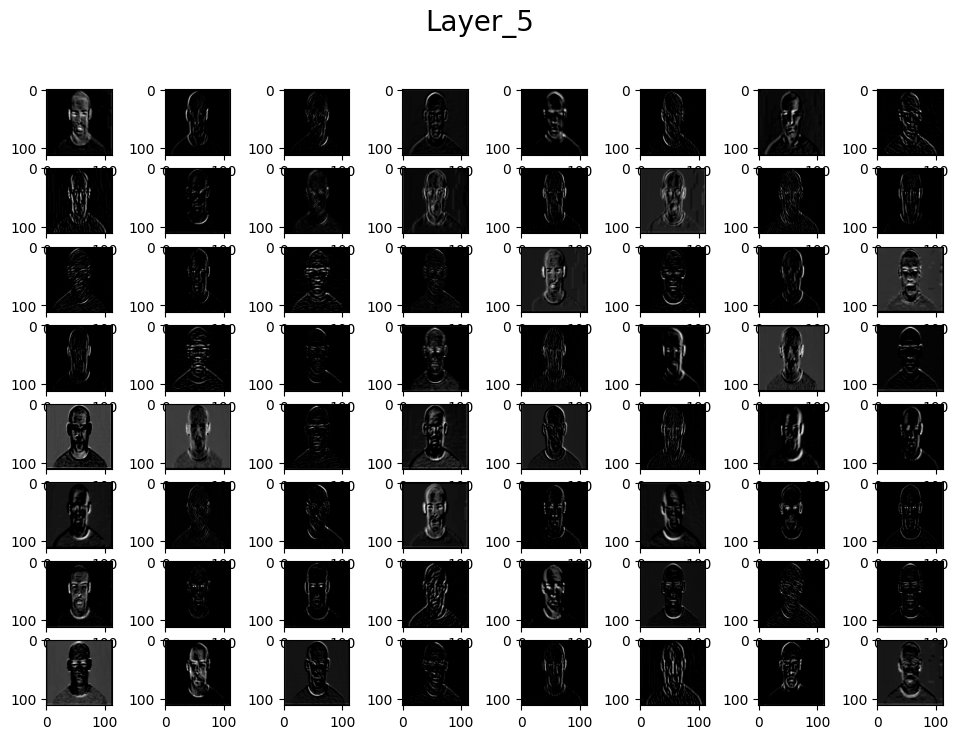

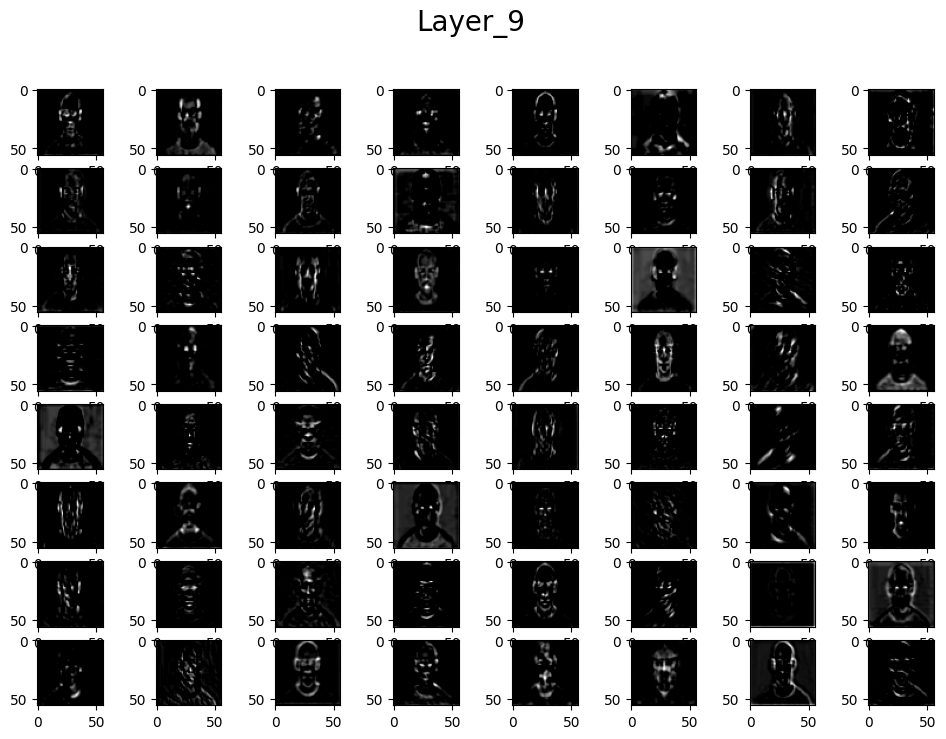

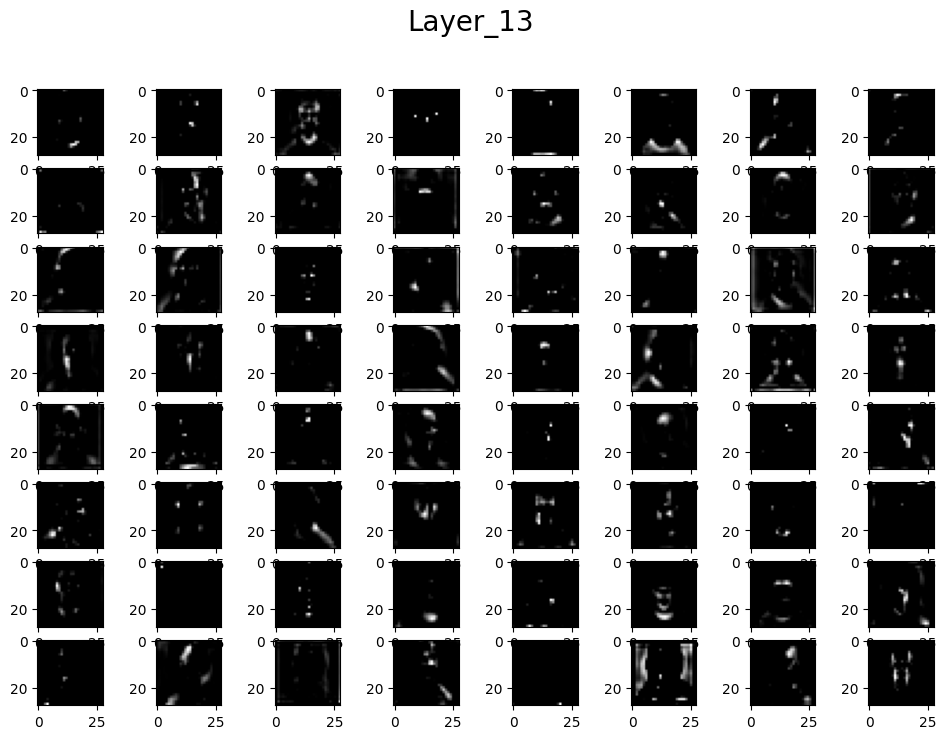

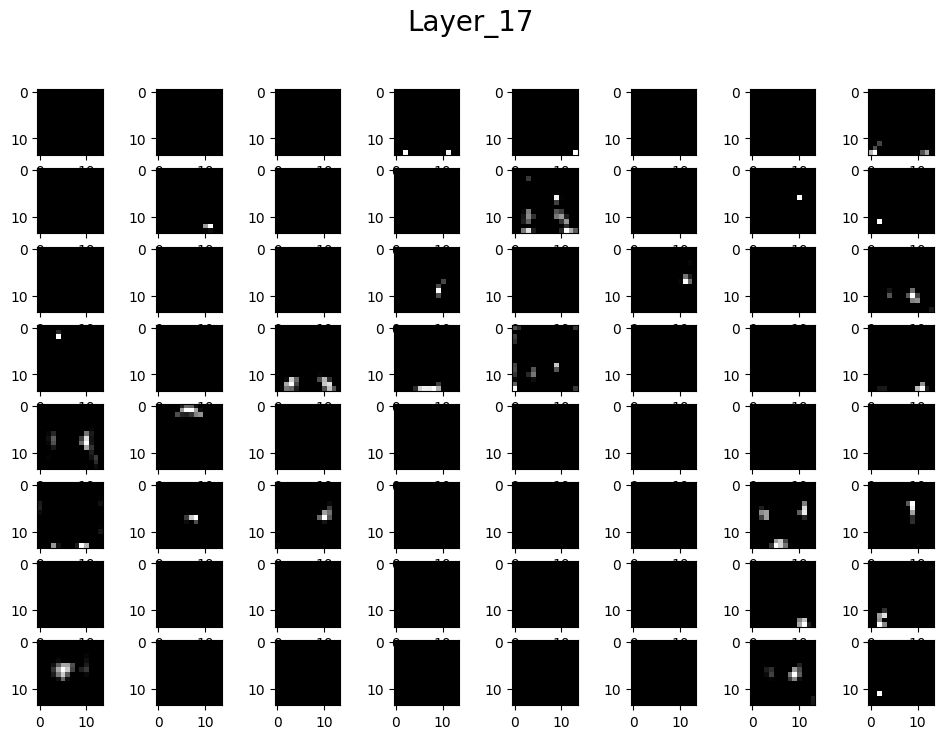

In [38]:
feature_map = model3.predict(image)

for i,fmap in zip(layer_index,feature_map):
  fig = pyplot.figure(figsize = (12,8))
  fig.suptitle('Layer_{}'.format(i),fontsize = 20)
  for i in range(1,features.shape[3]+1):

    pyplot.subplot(8,8,i)
    pyplot.imshow(fmap[0,:,:,i-1],cmap = 'gray')

pyplot.show()